In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Читаємо файл. Додаємо encoding='latin-1'
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')

# Конвертуємо кількість прослуховувань у числовий тип
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
df = df.dropna(subset=['streams']) # видаляємо рядки, де немає даних про стріми

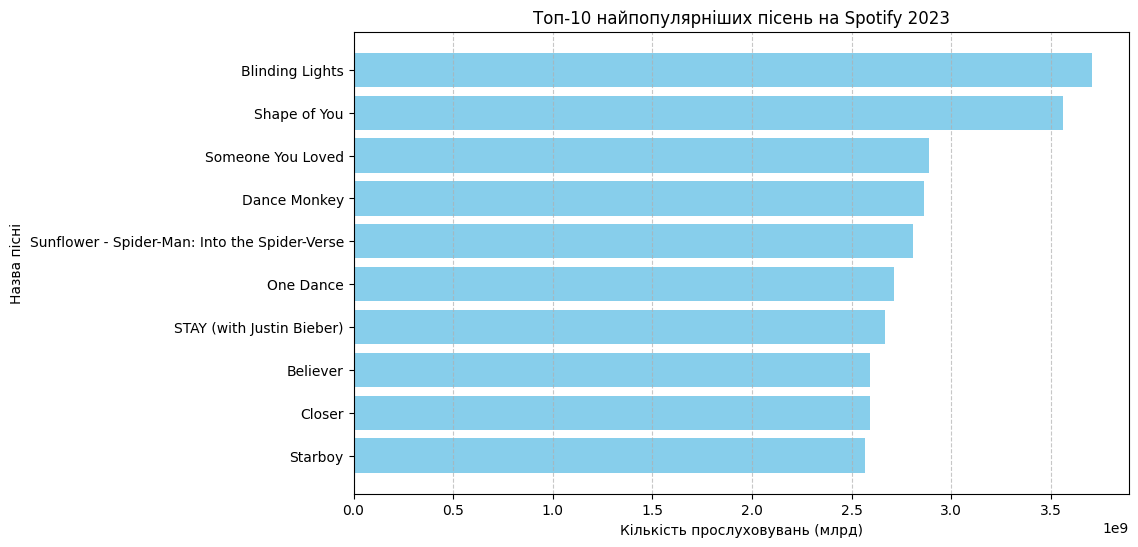

In [2]:
# Сортуємо за прослуховуваннями та беремо топ-10
top_10_songs = df.nlargest(10, 'streams')

plt.figure(figsize=(10, 6))
plt.barh(top_10_songs['track_name'], top_10_songs['streams'], color='skyblue')
plt.xlabel('Кількість прослуховувань (млрд)')
plt.ylabel('Назва пісні')
plt.title('Топ-10 найпопулярніших пісень на Spotify 2023')
plt.gca().invert_yaxis() # щоб найпопулярніша була зверху
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

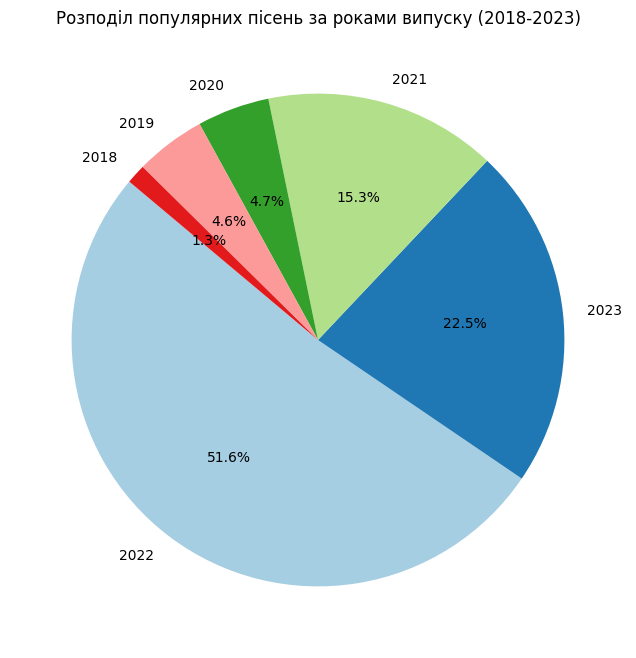

In [3]:
# Розподіл пісень за роками випуску (візьмемо останні 5 років)
years_dist = df[df['released_year'] >= 2018]['released_year'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(years_dist, labels=years_dist.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Розподіл популярних пісень за роками випуску (2018-2023)')
plt.show()

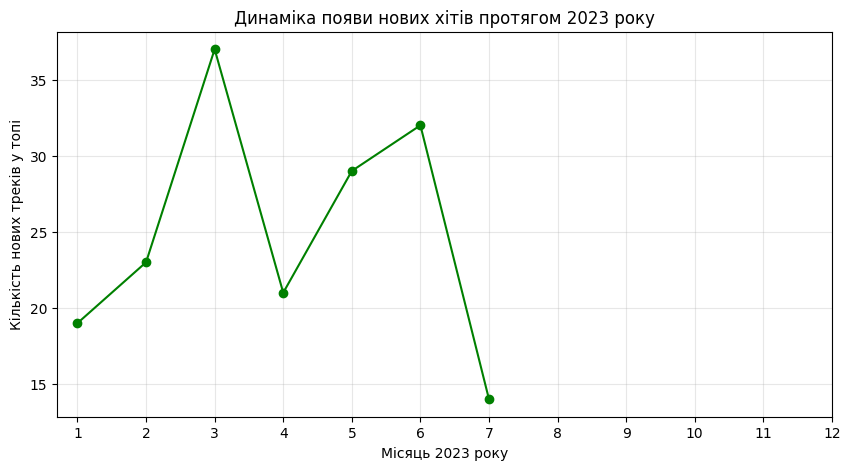

In [4]:
# Оскільки в датасеті дані за рік зафіксовані, відобразимо кількість релізів по місяцях 2023 року
df_2023 = df[df['released_year'] == 2023]
monthly_releases = df_2023['released_month'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(monthly_releases.index, monthly_releases.values, marker='o', linestyle='-', color='green')
plt.xticks(range(1, 13))
plt.xlabel('Місяць 2023 року')
plt.ylabel('Кількість нових треків у топі')
plt.title('Динаміка появи нових хітів протягом 2023 року')
plt.grid(True, alpha=0.3)
plt.show()

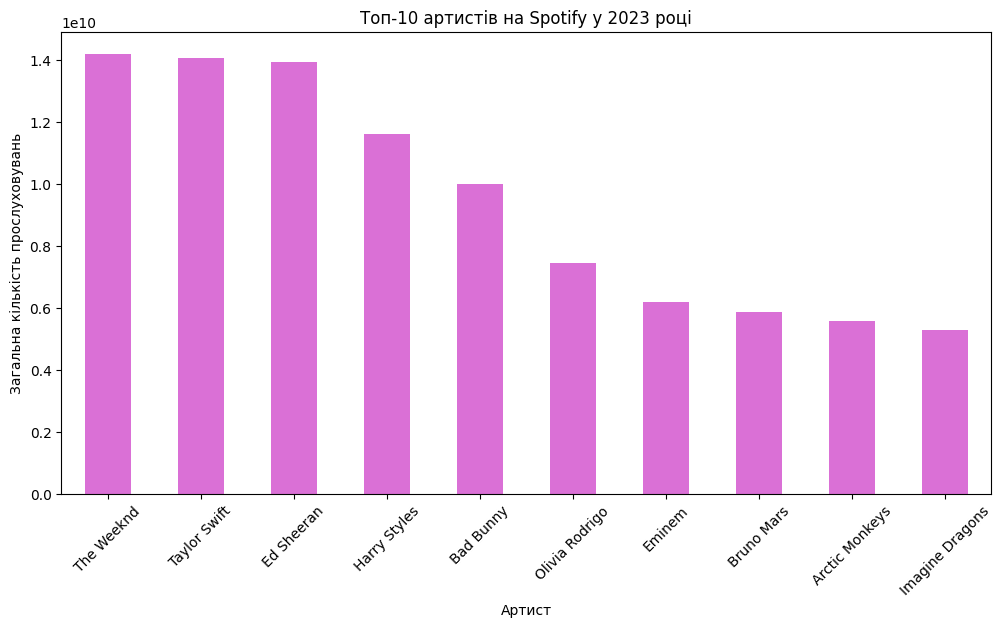

In [5]:
# Рахуємо загальну кількість стрімів для кожного артиста
top_artists = df.groupby('artist(s)_name')['streams'].sum().nlargest(10)

plt.figure(figsize=(12, 6))
top_artists.plot(kind='bar', color='orchid')
plt.xlabel('Артист')
plt.ylabel('Загальна кількість прослуховувань')
plt.title('Топ-10 артистів на Spotify у 2023 році')
plt.xticks(rotation=45)
plt.show()

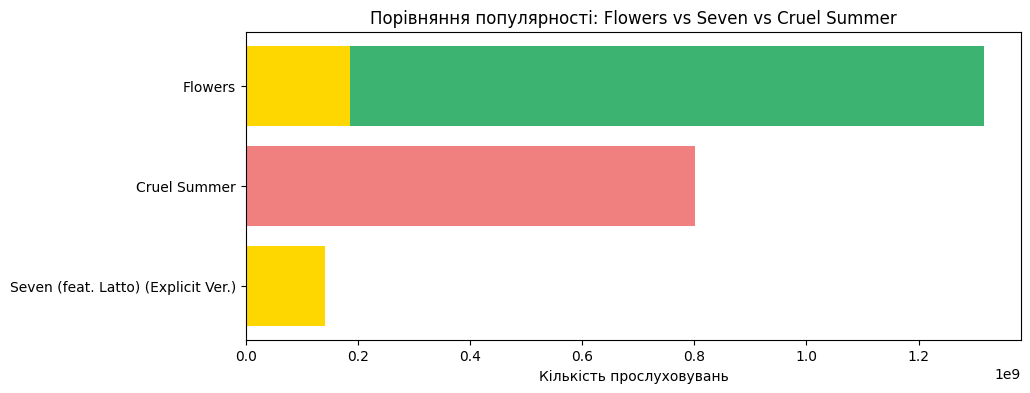

In [6]:
# Вибираємо три треки (можна змінити назви на будь-які зі списку)
target_tracks = df[df['track_name'].isin(['Flowers', 'Seven (feat. Latto) (Explicit Ver.)', 'Cruel Summer'])]

plt.figure(figsize=(10, 4))
plt.barh(target_tracks['track_name'], target_tracks['streams'], color=['gold', 'lightcoral', 'mediumseagreen'])
plt.xlabel('Кількість прослуховувань')
plt.title('Порівняння популярності: Flowers vs Seven vs Cruel Summer')
plt.show()